# DR Criterion Study
### ttH(bb) dilepton — mass reco combination selection analysis
Compares max_weight-only selection vs DR-criterion selection across all 4 ranks.

In [47]:
from coffea.util import load
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import hist
import warnings
warnings.filterwarnings('ignore')

# ── paths ──────────────────────────────────────────────────────────────────
COFFEA_FILE = '/eos/home-i04/p/piosifid/PocketCoffea/ANN_newCoffea/DATA_MassReco/test_all_2/output_all.coffea'
DATASET  = 'TTH_Hto2B'
CATEGORY = 'baseline_all_atleast4bjets'

out = load(COFFEA_FILE)
print('Top-level keys:', list(out.keys())[:10], '...')

variables = out['variables']
h_container = variables['rank_used']
print(type(h_container))
print(list(h_container.keys()))
first_key = list(h_container.keys())[0]
print(type(h_container[first_key]))
print(list(h_container[first_key].keys()))
second_key = list(h_container[first_key].keys())[0]
print(type(h_container[first_key][second_key]))
print(h_container[first_key][second_key])
variables = out["variables"]
all_vars = list(variables.keys())
print(f"Total histograms: {len(all_vars)}")

# Check the new ones are there
new_vars = [v for v in all_vars if any(k in v.lower() for k in
            ['rejected', 'chosen_from', 'rank1', 'rank2', 'rank3', 'rank4',
             'fallback', 'truth_vs_reco', 'dr_vs_mass'])]
print("\nNew DR study histograms:")
for v in sorted(new_vars):
    print(' ', v)

Top-level keys: ['sum_genweights', 'sum_signOf_genweights', 'sumw', 'sumw2', 'cutflow', 'variables', 'columns', 'processing_metadata', 'datasets_metadata'] ...
<class 'collections.defaultdict'>
['TTH_Hto2B']
<class 'dict'>
['TTH_Hto2B_2024']
<class 'hist.hist.Hist'>
Hist(
  StrCategory(['baseline_all', 'baseline_all_atleast2bjets', 'baseline_all_atleast3bjets', 'baseline_all_atleast4bjets'], name='cat', label='Category'),
  StrCategory(['nominal'], name='variation', label='Variation'),
  Regular(6, -1, 5, name='events.rank_used', label='Rank used by DR criterion'),
  storage=Weight()) # Sum: WeightedSum(value=22180, variance=22180)
Total histograms: 103

New DR study histograms:
  dr_chosen_from_fallback
  dr_chosen_from_rank1
  dr_chosen_from_rank2
  dr_chosen_from_rank3
  dr_chosen_from_rank4
  dr_rank1
  dr_rank1_rejected
  dr_rank2
  dr_rank2_rejected
  dr_rank3
  dr_rank3_rejected
  dr_rank4
  dr_rank4_rejected
  dr_vs_mass_rank1_rejected
  dr_vs_mass_rank1_selected
  dr_vs_mass_r

In [15]:
# ── helper: extract 1D histogram values and bin centres ──────────────────
def get_hist(out, var, dataset=DATASET, category=CATEGORY):
    h = out['variables'][var][dataset]['TTH_Hto2B_2024']
    h = h[{'cat': category, 'variation': 'nominal'}]
    vals  = h.values()
    edges = h.axes[0].edges
    return vals, edges

def centres(edges):
    return 0.5 * (edges[:-1] + edges[1:])

def integral(vals, edges):
    widths = np.diff(edges)
    return np.sum(vals * widths)

# ── style ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f8f8',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.size':        12,
})

COLORS = {
    'rank1': '#2166ac',
    'rank2': '#f4a582',
    'rank3': '#d6604d',
    'rank4': '#92c5de',
    'maxweight': '#2166ac',
    'dr':        '#d6604d',
    'truth':     '#4dac26',
}

print('Helpers loaded.')

Helpers loaded.


## Step 1 — Check available histograms

In [16]:
variables = out["variables"]
all_vars = list(variables.keys())
dr_vars  = [v for v in all_vars if any(k in v.lower() for k in
             ['rank', 'dr_', 'correct_match', 'maxweight', 'chosen', 'truth', 'pair_in', 'mass_reco_had'])]
print('DR-study related histograms found:')
for v in sorted(dr_vars):
    print(' ', v)
print(f'\nTotal histograms in file: {len(all_vars)}')

DR-study related histograms found:
  Massreco_chosen_pair_all_higgs_mass
  Massreco_chosen_pair_correct_dr
  Massreco_chosen_pair_correct_higgs_mass
  Massreco_chosen_pair_correct_jet_pt
  Massreco_chosen_pair_higgs_mass
  Massreco_chosen_pair_higgs_mass_1
  Massreco_chosen_pair_higgs_mass_2
  Massreco_chosen_pair_higgs_mass_3
  Massreco_chosen_pair_higgs_mass_4
  Massreco_chosen_pair_wrong_dr
  Massreco_chosen_pair_wrong_higgs_mass
  Massreco_chosen_pair_wrong_higgs_mass_1_jets
  Massreco_chosen_pair_wrong_higgs_mass_2_jets
  correct_match_dr
  correct_match_maxweight
  dR_b1_b2
  dr_chosen
  dr_rank1
  dr_rank2
  dr_rank3
  dr_rank4
  higgs_mass_chosen
  higgs_mass_rank1
  higgs_mass_rank2
  higgs_mass_rank3
  higgs_mass_rank4
  mass_reco_had_a_solution
  massreco_maxweight_higgs_mass
  pair_dr_truth
  pair_in_the_4leading
  pair_in_the_4leadingbtagscore
  pair_mass_truth
  rank_used

Total histograms in file: 90


## Group 1 — DR Criterion Activity
### Plot 1.1 — How often does each rank get used?

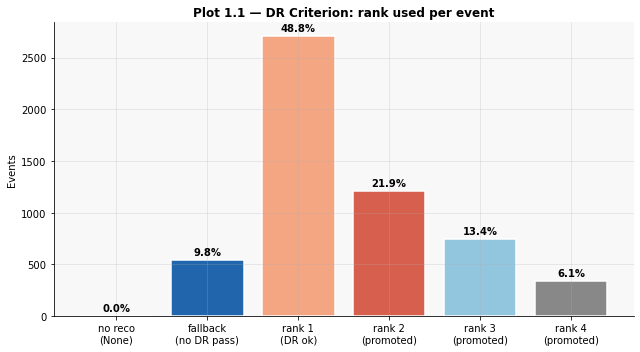

In [29]:
vals, edges = get_hist(out, 'rank_used')
rank_labels = ['no reco\n(None)', 'fallback\n(no DR pass)', 'rank 1\n(DR ok)',
               'rank 2\n(promoted)', 'rank 3\n(promoted)', 'rank 4\n(promoted)']

fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = ['#cccccc', COLORS['rank1'], COLORS['rank2'], COLORS['rank3'], COLORS['rank4'], '#888888']
bars = ax.bar(range(len(vals)), vals, color=bar_colors, edgecolor='white', linewidth=1.5)

total = vals.sum()
for i, (bar, v) in enumerate(zip(bars, vals)):
    pct = 100 * v / max(1, total)
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + total*0.005,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(range(len(vals)))
ax.set_xticklabels(rank_labels, fontsize=10)
ax.set_ylabel('Events')
ax.set_title('Plot 1.1 — DR Criterion: rank used per event', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_1_1_rank_used.png', dpi=150)
plt.show()

## Group 2 — Kinematics per rank
### Plot 2.1 — Higgs mass distributions per rank

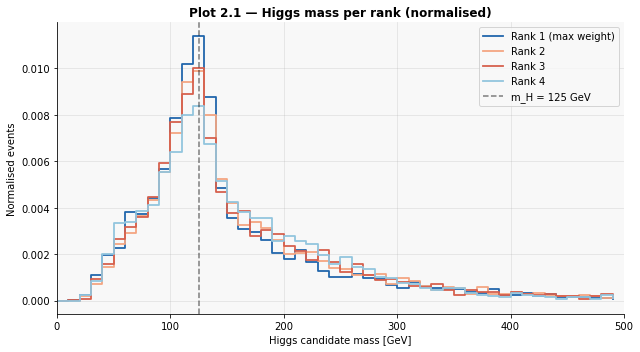

In [18]:
fig, ax = plt.subplots(figsize=(9, 5))

for rank, color, label in [
    ('higgs_mass_rank1', COLORS['rank1'], 'Rank 1 (max weight)'),
    ('higgs_mass_rank2', COLORS['rank2'], 'Rank 2'),
    ('higgs_mass_rank3', COLORS['rank3'], 'Rank 3'),
    ('higgs_mass_rank4', COLORS['rank4'], 'Rank 4'),
]:
    try:
        v, e = get_hist(out, rank)
        norm = integral(v, e)
        ax.step(e[:-1], v / max(1, norm), where='post', color=color, label=label, linewidth=1.8)
    except Exception as ex:
        print(f'  Skipping {rank}: {ex}')

ax.axvline(125, color='black', linestyle='--', alpha=0.5, label='m_H = 125 GeV')
ax.set_xlabel('Higgs candidate mass [GeV]')
ax.set_ylabel('Normalised events')
ax.set_xlim(0, 500)
ax.legend()
ax.set_title('Plot 2.1 — Higgs mass per rank (normalised)', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_2_1_higgs_mass_per_rank.png', dpi=150)
plt.show()

### Plot 2.2 — DR distributions per rank

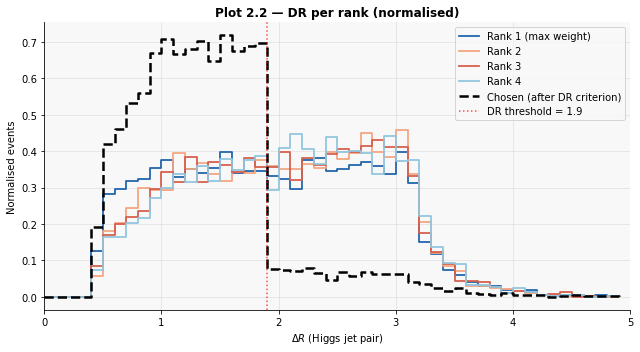

In [19]:
fig, ax = plt.subplots(figsize=(9, 5))

for rank, color, label in [
    ('dr_rank1', COLORS['rank1'], 'Rank 1 (max weight)'),
    ('dr_rank2', COLORS['rank2'], 'Rank 2'),
    ('dr_rank3', COLORS['rank3'], 'Rank 3'),
    ('dr_rank4', COLORS['rank4'], 'Rank 4'),
    ('dr_chosen', 'black',        'Chosen (after DR criterion)'),
]:
    try:
        v, e = get_hist(out, rank)
        norm = integral(v, e)
        ls = '-' if rank != 'dr_chosen' else '--'
        lw = 1.8 if rank != 'dr_chosen' else 2.5
        ax.step(e[:-1], v / max(1, norm), where='post', color=color,
                label=label, linewidth=lw, linestyle=ls)
    except Exception as ex:
        print(f'  Skipping {rank}: {ex}')

ax.axvline(1.9, color='red', linestyle=':', alpha=0.7, label='DR threshold = 1.9')
ax.set_xlabel(r'$\Delta R$ (Higgs jet pair)')
ax.set_ylabel('Normalised events')
ax.set_xlim(0, 5)
ax.legend()
ax.set_title('Plot 2.2 — DR per rank (normalised)', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_2_2_dr_per_rank.png', dpi=150)
plt.show()

## Group 3 — Truth matching per rank
### Plot 3.1 — correct_match distribution: max_weight vs DR criterion

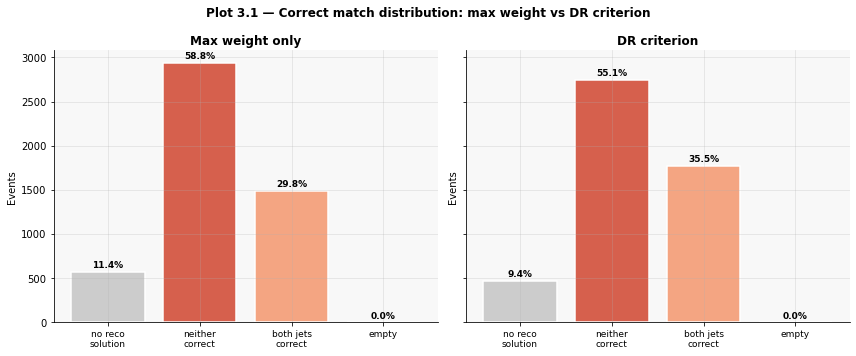

edges: [0. 1. 2. 3. 4.]
values: [ 471. 2750. 1772.    0.]
edges mw: [0. 1. 2. 3. 4.]
values mw: [ 571. 2935. 1487.    0.]


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

match_labels = ['no reco\nsolution', 'neither\ncorrect', 'both jets\ncorrect', 'empty']
match_colors = ['#cccccc', '#d6604d', '#f4a582', '#2166ac']

for ax, var, title in [
    (axes[0], 'correct_match_maxweight', 'Max weight only'),
    (axes[1], 'correct_match_dr',        'DR criterion'),
]:
    try:
        v, e = get_hist(out, var)
        total = v.sum()
        bars = ax.bar(range(len(v)), v, color=match_colors[:len(v)],
                      edgecolor='white', linewidth=1.5)
        for bar, val in zip(bars, v):
            pct = 100 * val / max(1, total)
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + total*0.005,
                    f'{pct:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
        ax.set_xticks(range(len(v)))
        ax.set_xticklabels(match_labels[:len(v)], fontsize=9)
        ax.set_title(title, fontweight='bold')
        ax.set_ylabel('Events')
    except Exception as ex:
        print(f'  Skipping {var}: {ex}')

fig.suptitle('Plot 3.1 — Correct match distribution: max weight vs DR criterion', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_3_1_correct_match_comparison.png', dpi=150)
plt.show()

v, e = get_hist(out, 'correct_match_dr')
print('edges:', e)
print('values:', v)

v2, e2 = get_hist(out, 'correct_match_maxweight')
print('edges mw:', e2)
print('values mw:', v2)

### Plot 3.2 — Promotion category breakdown
Derived from `rank_used`, `correct_match_maxweight`, `correct_match_dr`

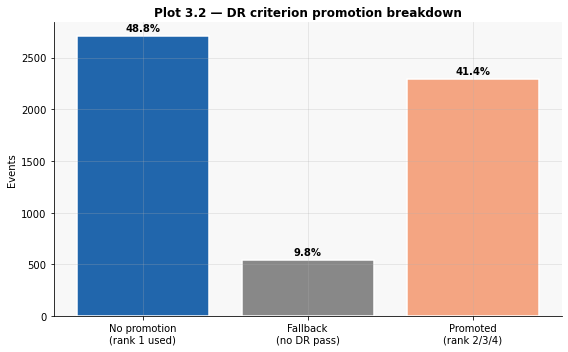

edges: [-1.00000000e+00 -1.11022302e-16  1.00000000e+00  2.00000000e+00
  3.00000000e+00  4.00000000e+00  5.00000000e+00]
values: [   0.  544. 2705. 1213.  742.  341.]


In [28]:
# We approximate promotion categories from the histograms
# rank_used==1 → no promotion; rank_used in {2,3,4,0} → promoted
# For promoted events, we use correct_match_maxweight vs correct_match_dr

try:
    v_rank,  e_rank  = get_hist(out, 'rank_used')
    v_mw,    e_mw    = get_hist(out, 'correct_match_maxweight')
    v_dr,    e_dr    = get_hist(out, 'correct_match_dr')

    # rank_used bins: [-1,0,1,2,3,4,5] → no_reco, fallback, rank1, rank2, rank3, rank4
    n_no_reco    = v_rank[0]  # rank=None stored as -1
    n_fallback   = v_rank[1]  # rank=0
    n_rank1      = v_rank[2]  # rank=1
    n_promoted   = v_rank[3] + v_rank[4] + v_rank[5]  # ranks 2,3,4

    # correct_match bins: 0=no reco, 1=neither, 2=one, 3=both (approximately)
    n_mw_correct = v_mw[-1] if len(v_mw) >= 3 else 0  # both correct
    n_dr_correct = v_dr[-1] if len(v_dr) >= 3 else 0

    categories = [
        ('No promotion\n(rank 1 used)',   n_rank1,    '#2166ac'),
        ('Fallback\n(no DR pass)',         n_fallback, '#888888'),
        ('Promoted\n(rank 2/3/4)',         n_promoted, '#f4a582'),
    ]

    fig, ax = plt.subplots(figsize=(8, 5))
    labels, counts, colors = zip(*categories)
    bars = ax.bar(labels, counts, color=colors, edgecolor='white', linewidth=1.5)
    total = sum(counts)
    for bar, v in zip(bars, counts):
        pct = 100 * v / max(1, total)
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + total*0.005,
                f'{pct:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_ylabel('Events')
    ax.set_title('Plot 3.2 — DR criterion promotion breakdown', fontweight='bold')
    plt.tight_layout()
    plt.savefig('plot_3_2_promotion_breakdown.png', dpi=150)
    plt.show()

except Exception as ex:
    print(f'Could not make plot 3.2: {ex}')


v_rank, e_rank = get_hist(out, 'rank_used')
print('edges:', e_rank)
print('values:', v_rank)

### Plot 3.3 — Higgs mass: correct vs wrong, for max_weight and DR criterion

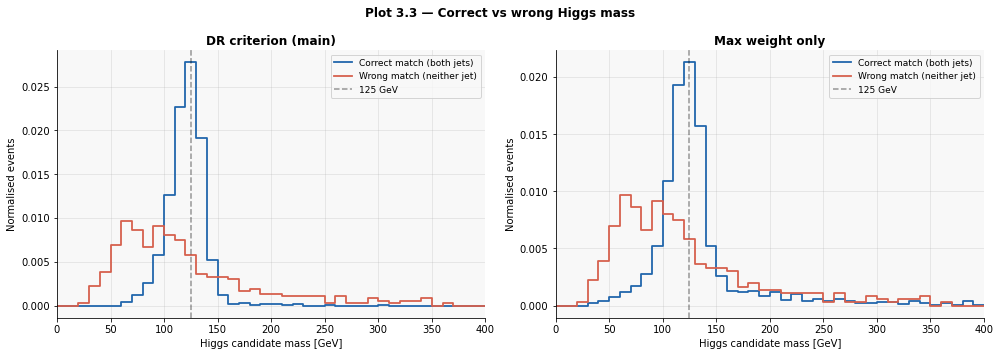

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, correct_var, wrong_var, title in [
    (axes[0],
     'Massreco_chosen_pair_correct_higgs_mass',
     'Massreco_chosen_pair_wrong_higgs_mass',
     'DR criterion (main)'),
    (axes[1],
     'massreco_maxweight_higgs_mass',
     'Massreco_chosen_pair_wrong_higgs_mass',
     'Max weight only'),
]:
    for var, color, label in [
        (correct_var, COLORS['rank1'], 'Correct match (both jets)'),
        (wrong_var,   COLORS['rank3'], 'Wrong match (neither jet)'),
    ]:
        try:
            v, e = get_hist(out, var)
            norm = integral(v, e)
            ax.step(e[:-1], v / max(1, norm), where='post',
                    color=color, label=label, linewidth=1.8)
        except Exception as ex:
            print(f'  Skipping {var}: {ex}')

    ax.axvline(125, color='black', linestyle='--', alpha=0.4, label='125 GeV')
    ax.set_xlabel('Higgs candidate mass [GeV]')
    ax.set_ylabel('Normalised events')
    ax.set_xlim(0, 400)
    ax.legend(fontsize=9)
    ax.set_title(title, fontweight='bold')

fig.suptitle('Plot 3.3 — Correct vs wrong Higgs mass', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_3_3_correct_vs_wrong_mass.png', dpi=150)
plt.show()

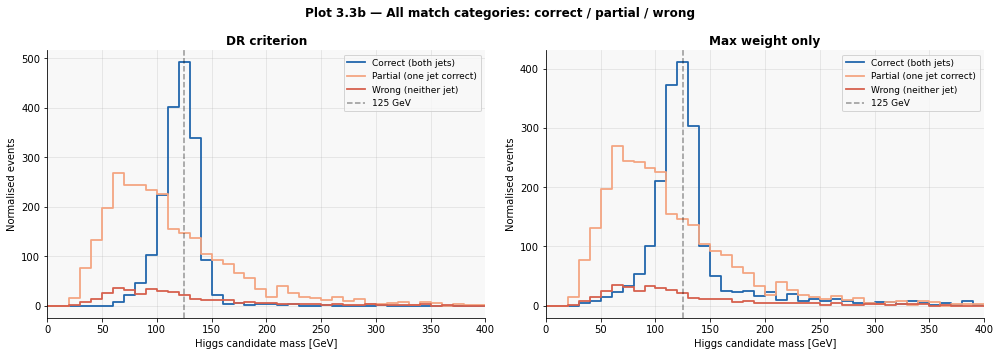

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, title, correct_var, partial_var, wrong_var in [
    (axes[0], 'DR criterion',
     'Massreco_chosen_pair_correct_higgs_mass',
     'Massreco_chosen_pair_wrong_higgs_mass_1_jets',
     'Massreco_chosen_pair_wrong_higgs_mass'),
    (axes[1], 'Max weight only',
     'massreco_maxweight_higgs_mass',
     'Massreco_chosen_pair_wrong_higgs_mass_1_jets',
     'Massreco_chosen_pair_wrong_higgs_mass'),
]:
    for var, color, label in [
        (correct_var, COLORS['rank1'],  'Correct (both jets)'),
        (partial_var, '#f4a582',        'Partial (one jet correct)'),
        (wrong_var,   COLORS['rank3'],  'Wrong (neither jet)'),
    ]:
        try:
            v, e = get_hist(out, var)
            norm = integral(v, e)
            ax.step(e[:-1], v , where='post',
                    color=color, label=label, linewidth=1.8)
        except Exception as ex:
            print(f'  Skipping {var}: {ex}')

    ax.axvline(125, color='black', linestyle='--', alpha=0.4, label='125 GeV')
    ax.set_xlabel('Higgs candidate mass [GeV]')
    ax.set_ylabel('Normalised events')
    ax.set_xlim(0, 400)
    ax.legend(fontsize=9)
    ax.set_title(title, fontweight='bold')

fig.suptitle('Plot 3.3b — All match categories: correct / partial / wrong', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_3_3b_all_categories_mass.png', dpi=150)
plt.show()

## Group 4 — Bottom line comparison
### Plot 4.1 — Overall Higgs mass: max_weight vs DR criterion

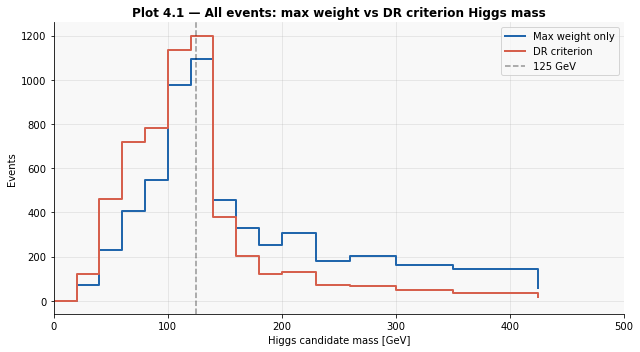

max_weight total: 5414.0
higgs_mass_chosen total: 5491.0
edges: [  0.  20.  40.  60.  80. 100. 120. 140. 160. 180. 200. 230. 260. 300.
 350. 425. 500.]
total: 5491.0


In [41]:
fig, ax = plt.subplots(figsize=(9, 5))

for var, color, label in [
    ('Max_Weight_Higgs_Mass', COLORS['maxweight'], 'Max weight only'),
    ('Massreco_chosen_pair_higgs_mass_4',     COLORS['dr'],        'DR criterion'),
]:
    try:
        v, e = get_hist(out, var)
        norm = integral(v, e)
        ax.step(e[:-1], v , where='post',
                color=color, label=label, linewidth=2)
    except Exception as ex:
        print(f'  Skipping {var}: {ex}')

ax.axvline(125, color='black', linestyle='--', alpha=0.4, label='125 GeV')
ax.set_xlabel('Higgs candidate mass [GeV]')
ax.set_ylabel('Events')
ax.set_xlim(0, 500)
ax.legend()
ax.set_title('Plot 4.1 — All events: max weight vs DR criterion Higgs mass', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_4_1_overall_mass_comparison.png', dpi=150)
plt.show()

v1, e1 = get_hist(out, 'Max_Weight_Higgs_Mass')
v2, e2 = get_hist(out, 'higgs_mass_chosen')
print('max_weight total:', v1.sum())
print('higgs_mass_chosen total:', v2.sum())
v, e = get_hist(out, 'Massreco_chosen_pair_higgs_mass_4')
print('edges:', e)
print('total:', v.sum())

### Plot 4.2 — Correct match Higgs mass & Plot 4.2b — Wrong match Higgs mass

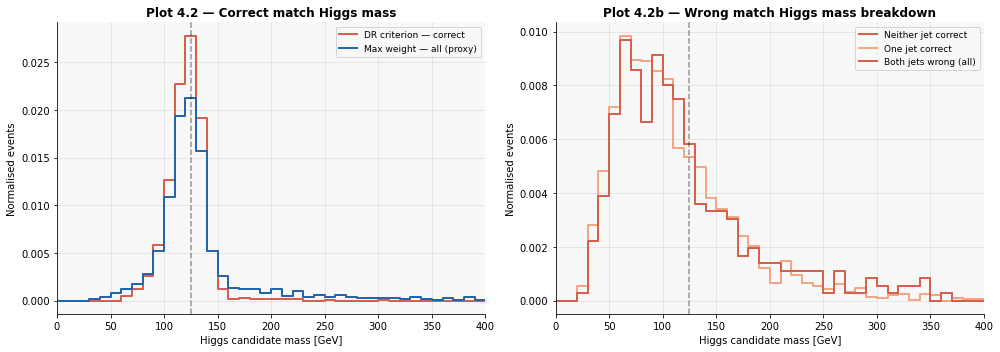

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 4.2 — correct match: DR criterion vs max weight
ax = axes[0]
for var, color, label in [
    ('Massreco_chosen_pair_correct_higgs_mass', COLORS['dr'],        'DR criterion — correct'),
    ('massreco_maxweight_higgs_mass',           COLORS['maxweight'], 'Max weight — all (proxy)'),
]:
    try:
        v, e = get_hist(out, var)
        norm = integral(v, e)
        ax.step(e[:-1], v / max(1, norm), where='post',
                color=color, label=label, linewidth=2)
    except Exception as ex:
        print(f'  Skipping {var}: {ex}')
ax.axvline(125, color='black', linestyle='--', alpha=0.4)
ax.set_xlabel('Higgs candidate mass [GeV]')
ax.set_ylabel('Normalised events')
ax.set_xlim(0, 400)
ax.legend(fontsize=9)
ax.set_title('Plot 4.2 — Correct match Higgs mass', fontweight='bold')

# Plot 4.2b — wrong match breakdown
ax = axes[1]
for var, color, label in [
    ('Massreco_chosen_pair_wrong_higgs_mass',        COLORS['dr'],  'Neither jet correct'),
    ('Massreco_chosen_pair_wrong_higgs_mass_1_jets', '#f4a582',     'One jet correct'),
    ('Massreco_chosen_pair_wrong_higgs_mass_2_jets', '#d6604d',     'Both jets wrong (all)'),
]:
    try:
        v, e = get_hist(out, var)
        norm = integral(v, e)
        ax.step(e[:-1], v / max(1, norm), where='post',
                color=color, label=label, linewidth=2)
    except Exception as ex:
        print(f'  Skipping {var}: {ex}')
ax.axvline(125, color='black', linestyle='--', alpha=0.4)
ax.set_xlabel('Higgs candidate mass [GeV]')
ax.set_ylabel('Normalised events')
ax.set_xlim(0, 400)
ax.legend(fontsize=9)
ax.set_title('Plot 4.2b — Wrong match Higgs mass breakdown', fontweight='bold')

plt.tight_layout()
plt.savefig('plot_4_2_correct_wrong_mass.png', dpi=150)
plt.show()

### Plot 4.3 — Efficiency: correct_match==2 rate, max_weight vs DR criterion

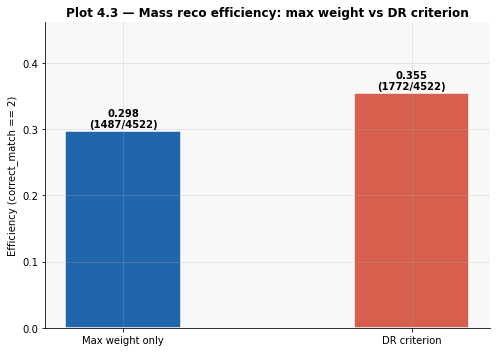


Summary:
  Max weight only: 0.298 (1487/4522)
  DR criterion: 0.355 (1772/4522)
  Delta (DR - maxweight): +0.057 (+5.7%)


In [43]:
fig, ax = plt.subplots(figsize=(7, 5))

results = {}
for var, label in [
    ('correct_match_maxweight', 'Max weight only'),
    ('correct_match_dr',        'DR criterion'),
]:
    try:
        v, e = get_hist(out, var)
        # bins: 0=no reco, 1=neither, 2=one, 3=both correct
        total = v[0] + v[1] + v[2]   # no_reco + neither + both_correct — same for all events
        both_correct = v[2]
        eff = both_correct / max(1, total)
        results[label] = (eff, both_correct, total_with_reco)
    except Exception as ex:
        print(f'  Could not compute efficiency for {var}: {ex}')
        results[label] = (0, 0, 0)

labels = list(results.keys())
effs   = [results[l][0] for l in labels]
colors = [COLORS['maxweight'], COLORS['dr']]

bars = ax.bar(labels, effs, color=colors, edgecolor='white', linewidth=1.5, width=0.4)
for bar, (label, (eff, n_correct, n_total)) in zip(bars, results.items()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{eff:.3f}\n({int(n_correct)}/{int(n_total)})',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Efficiency (correct_match == 2)')
ax.set_ylim(0, max(effs) * 1.3)
ax.set_title('Plot 4.3 — Mass reco efficiency: max weight vs DR criterion', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_4_3_efficiency_comparison.png', dpi=150)
plt.show()

print('\nSummary:')
for label, (eff, n_correct, n_total) in results.items():
    print(f'  {label}: {eff:.3f} ({int(n_correct)}/{int(n_total)})')
if len(results) == 2:
    effs_list = list(results.values())
    delta = effs_list[1][0] - effs_list[0][0]
    print(f'  Delta (DR - maxweight): {delta:+.3f} ({delta*100:+.1f}%)')

### Plot 4.4 — Truth Higgs mass vs reco Higgs mass
*(Requires 2D histogram — add to config and rerun if not available)*

In [46]:
# Check if 2D histogram is available
try:
    h2d = out['truth_vs_reco_higgs_mass'][DATASET][CATEGORY]
    vals2d = h2d.values()
    ex = h2d.axes[0].edges
    ey = h2d.axes[1].edges

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    for ax, var2d, title in [
        (axes[0], 'truth_vs_reco_higgs_mass_maxweight', 'Max weight only'),
        (axes[1], 'truth_vs_reco_higgs_mass',           'DR criterion'),
    ]:
        try:
            h = out[var2d][DATASET][CATEGORY]
            im = ax.pcolormesh(h.axes[0].edges, h.axes[1].edges,
                               h.values().T, cmap='Blues')
            plt.colorbar(im, ax=ax, label='Events')
            ax.plot([0, 500], [0, 500], 'r--', alpha=0.5, label='truth = reco')
            ax.set_xlabel('Truth Higgs mass [GeV]')
            ax.set_ylabel('Reco Higgs mass [GeV]')
            ax.set_title(title, fontweight='bold')
            ax.legend()
        except Exception as ex:
            print(f'  {var2d} not available: {ex}')

    fig.suptitle('Plot 4.4 — Truth vs reco Higgs mass 2D', fontweight='bold')
    plt.tight_layout()
    plt.savefig('plot_4_4_truth_vs_reco_2d.png', dpi=150)
    plt.show()

except:
    print('Plot 4.4: 2D histogram not in coffea file.')
    print('Add truth_vs_reco_higgs_mass to the config and rerun to enable this plot.')

Plot 4.4: 2D histogram not in coffea file.
Add truth_vs_reco_higgs_mass to the config and rerun to enable this plot.


## Summary

In [ ]:
print('All plots saved:')
import glob
for f in sorted(glob.glob('plot_*.png')):
    print(' ', f)